# 🚗 Dynamic Pricing Implementation
## Dissertation: *Algorithmic Bias in Dynamic Pricing — A Business Analytics Investigation into Fairness, Profit Optimisation, and Consumer Trust*

---

### 📌 Datasets Used
| Dataset | Rows | Description |
|---|---|---|
| `dynamic_pricing__1_.csv` | 1,000 | Rideshare demand features: riders, drivers, location, loyalty, ratings, time, vehicle, duration, cost |
| `rideshare_kaggle.csv` | 637,976 (after cleaning) | Uber/Lyft Boston: price, distance, surge, hour, weather, routes |

---

### 📋 Notebook Structure
| Section | Topic |
|---|---|
| **Section 1** | Dynamic Pricing vs Algorithmic Pricing — Key Differences |
| **Section 2** | Data Loading & Cleaning |
| **Section 3** | Dimension 1 — People: Loyalty & Segmentation Pricing |
| **Section 4** | Dimension 2 — Product: Vehicle-Type & Tier Pricing |
| **Section 5** | Dimension 3 — Period: Temporal & Surge Pricing |
| **Section 6** | Dimension 4 — Place: Geographic & Route Pricing |
| **Section 7** | Algorithmic Pricing Model (Gradient Boosting Regressor) |
| **Section 8** | Bias Detection & Fairness Audit (Mehrabi et al., 2021) |
| **Section 9** | Consumer Trust Proxy (Vomberg et al., 2025) |
| **Section 10** | Revenue Optimisation: Static vs Full 4P Dynamic Pricing |
| **Section 11** | Visualisation Dashboard |
| **Section 12** | Summary & Key Findings |


---
## 📖 Section 1 — Dynamic Pricing vs Algorithmic Pricing: Key Differences

Understanding the distinction between these two closely related but conceptually distinct terms is essential for this dissertation.

---

### 1.1 Definition: Dynamic Pricing

**Dynamic pricing** is a *business strategy* — a pricing philosophy in which a firm deliberately changes prices in response to shifts in underlying market conditions. It is defined by **what changes** (the price) and **why it changes** (a change in one of the 4 Ps of demand):

> *"Dynamic pricing refers to price changes that are prompted by changes or differences in four key underlying market demand drivers: (1) People, (2) Product configurations, (3) Periods, and (4) Places."*
> — Kopalle, Pauwels, Akella & Gangwar (2023)

Dynamic pricing is the **goal or outcome** — it describes the pricing behaviour observed in the market. Its opposite is **static pricing** (one uniform price across all conditions).

**Examples of dynamic pricing (non-algorithmic):**
- A market vendor lowering vegetable prices in the afternoon as stock ages
- An airline charging more for tickets booked at the last minute
- A hotel adjusting weekend rates manually based on expected occupancy
- A retailer running seasonal sales or end-of-line discounts

---

### 1.2 Definition: Algorithmic Pricing

**Algorithmic pricing** is a *technological mechanism* — the use of data-driven algorithms and AI systems to **automate** price-setting decisions. It is defined by **how** prices are set (via code and computation).

> *"Algorithmic pricing refers to data-analytics-based pricing algorithms that allow firms to automatically generate dynamic or personalized prices."*
> — Vomberg, Homburg & Sarantopoulos (2025)

Algorithmic pricing is the **tool or means** — it is the computational engine that makes dynamic pricing scalable, real-time, and personalised. An algorithm can implement dynamic pricing, but dynamic pricing does not require an algorithm.

**Examples of algorithmic pricing:**
- Amazon changing millions of product prices daily using ML models
- Uber's surge pricing algorithm monitoring supply/demand ratios every minute
- Airline revenue management systems forecasting demand and setting fares automatically
- E-commerce repricing bots that match competitor prices in real time

---

### 1.3 Comparative Framework

| Dimension | Dynamic Pricing | Algorithmic Pricing |
|---|---|---|
| **Type** | Business strategy / pricing philosophy | Technological mechanism / implementation tool |
| **Definition** | Prices change in response to demand drivers (People, Product, Period, Place) | Automated price-setting via data-analytics and AI algorithms |
| **Focus** | *What* changes (price) and *why* (demand shifts) | *How* prices are set (automation, computation) |
| **Requires algorithm?** | ❌ No — can be manual (vendor intuition, manager decisions) | ✅ Yes — is inherently computational |
| **Requires price changes?** | ✅ Yes — static pricing is excluded by definition | ❌ Not necessarily — algorithm could set a single price |
| **Scale** | Can be small (individual vendor) or large | Typically large-scale; designed for volume |
| **Speed** | Can be slow (daily, weekly updates) | Typically real-time or near-real-time |
| **Personalisation** | Can be segment-level or individual | Enables true individual-level personalisation |
| **Transparency** | Often visible to consumer (sale signs, tiers) | Often opaque — consumers cannot see the algorithm |
| **Bias risk** | Lower — human decision makers notice outliers | Higher — bias in training data propagates silently |
| **Trust impact** | Moderate — consumers may accept visible rationale | Higher — unexplained price changes erode procedural fairness |
| **Regulatory risk** | Lower | Higher — e.g. GDPR limits on personal data use |
| **Key authors** | Kopalle et al. (2023); Talluri & Ryzin (2006) | Vomberg et al. (2025); Wang, Li & Kopalle (2022) |

---

### 1.4 The Relationship Between Them

The two concepts exist on a **spectrum of automation**:

```
Manual Dynamic Pricing ──────────────────────────► Fully Algorithmic Dynamic Pricing
  (vendor intuition)     (rules-based)  (ML model)      (deep RL, real-time AI)
        │                     │               │                    │
   No algorithm          Simple rules    Statistical          Autonomous
   Human sets price      Price if DSR>2  regression           self-learning
```

- **All algorithmic pricing is (usually) dynamic pricing**, because the algorithm's purpose is to change prices based on conditions.
- **Not all dynamic pricing is algorithmic** — a human manager who manually adjusts weekend hotel rates is practising dynamic pricing without any algorithm.
- **The ethical distinction matters**: when humans set prices, they are accountable; when algorithms set prices, accountability is diffused, and bias is harder to detect (Nunan & Di Domenico, 2022; Mehrabi et al., 2021).

---

### 1.5 Why This Distinction Matters for This Dissertation

This dissertation investigates **algorithmic bias in dynamic pricing** — a topic that sits precisely at the intersection of these two concepts:

1. **Dynamic pricing** provides the theoretical framework (4 Ps) and the revenue optimisation goal.
2. **Algorithmic pricing** is the mechanism through which dynamic pricing is implemented at scale — and the mechanism through which bias enters the system.

The Python implementation in this notebook practises **algorithmic dynamic pricing**: it uses a Gradient Boosting Regressor to set prices algorithmically, calibrated to the 4 Ps demand framework. The bias audit in Section 8 then examines whether the algorithm produces discriminatory price disparities across protected-attribute proxies.


---
## ⚙️ Section 2 — Data Loading & Cleaning

In [1]:
# ── Install / import all required libraries ──────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.labelsize": 10})

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


### 2.1 Load Dataset 1 — `dynamic_pricing.csv`

In [2]:
dp = pd.read_csv("C:\\Users\\user\\Downloads\\dynamic_pricing.csv")

print(f"Shape: {dp.shape}")
print(f"Null values: {dp.isnull().sum().sum()}")
print()
dp.head()


Shape: (1000, 10)
Null values: 0



,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [3]:
# Statistical summary of Dataset 1
dp.describe().round(2)


,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,60.37,27.08,50.03,4.26,99.59,372.50
std,23.70,19.07,29.31,0.44,49.17,187.16
min,20.00,5.00,0.00,3.50,10.00,25.99
25%,40.00,11.00,25.00,3.87,59.75,221.37
50%,60.00,22.00,51.00,4.27,102.00,362.02
75%,81.00,38.00,75.00,4.63,143.00,510.50
max,100.00,89.00,100.00,5.00,180.00,836.12


In [4]:
# Categorical value distributions
for col in ["Location_Category", "Customer_Loyalty_Status", "Time_of_Booking", "Vehicle_Type"]:
    print(f"{col}: {dp[col].value_counts().to_dict()}")


Location_Category: {'Urban': 346, 'Rural': 332, 'Suburban': 322}
Customer_Loyalty_Status: {'Silver': 367, 'Regular': 320, 'Gold': 313}
Time_of_Booking: {'Night': 276, 'Afternoon': 247, 'Morning': 246, 'Evening': 231}
Vehicle_Type: {'Premium': 522, 'Economy': 478}


### 2.2 Load Dataset 2 — `rideshare_kaggle.csv`

In [5]:
rs_raw = pd.read_csv("C:\\Users\\user\\Desktop\\Dissertation\\rideshare_kaggle.csv")
print(f"Raw shape: {rs_raw.shape}")
print(f"Null prices: {rs_raw['price'].isnull().sum():,}")

# Drop rows without price (target variable)
rs = rs_raw.dropna(subset=["price"]).copy()

# Select pricing-relevant columns only
keep_cols = [
    "cab_type", "name", "price", "distance", "surge_multiplier",
    "hour", "day", "month", "source", "destination",
    "temperature", "humidity", "windSpeed", "cloudCover", "precipProbability"
]
rs = rs[keep_cols].dropna()
print(f"After cleaning: {rs.shape}")
rs.head(3)


Raw shape: (693071, 57)
Null prices: 55,095
After cleaning: (637976, 15)


,cab_type,name,price,distance,surge_multiplier,hour,day,month,source,destination,temperature,humidity,windSpeed,cloudCover,precipProbability
0,Lyft,Shared,5.0,0.44,1.0,9,16,12,Haymarket Square,North Station,42.34,0.68,8.66,0.72,0.0
1,Lyft,Lux,11.0,0.44,1.0,2,27,11,Haymarket Square,North Station,43.58,0.94,11.98,1.00,1.0
2,Lyft,Lyft,7.0,0.44,1.0,1,28,11,Haymarket Square,North Station,38.33,0.75,7.33,0.03,0.0


### 2.3 Feature Engineering

In [6]:
# ── Dataset 1 features ──────────────────────────────────────────────────────
# Demand-Supply Ratio (DSR): proxy for market pressure
dp["demand_supply_ratio"] = dp["Number_of_Riders"] / dp["Number_of_Drivers"].clip(lower=1)

# Encode vehicle type
le_vt = LabelEncoder()
dp["vehicle_enc"] = le_vt.fit_transform(dp["Vehicle_Type"])

print("Dataset 1 — New features:")
print(dp[["demand_supply_ratio", "vehicle_enc"]].describe().round(3))


Dataset 1 — New features:
       demand_supply_ratio  vehicle_enc
count             1000.000     1000.000
mean                 3.235        0.522
std                  2.534        0.500
min                  1.112        0.000
25%                  1.659        0.000
50%                  2.357        1.000
75%                  3.800        1.000
max                 17.600        1.000


In [7]:
# ── Dataset 2 features ──────────────────────────────────────────────────────
rs["is_peak_hour"]   = rs["hour"].apply(lambda h: 1 if h in range(7, 10) or h in range(17, 20) else 0)
rs["is_night"]       = rs["hour"].apply(lambda h: 1 if h >= 22 or h <= 5 else 0)
rs["bad_weather"]    = ((rs["precipProbability"] > 0.4) | (rs["windSpeed"] > 15)).astype(int)
rs["price_per_mile"] = rs["price"] / rs["distance"].clip(lower=0.1)

print("Dataset 2 — Derived feature summary:")
print(rs[["is_peak_hour","is_night","bad_weather","price_per_mile"]].describe().round(3))


Dataset 2 — Derived feature summary:
       is_peak_hour    is_night  bad_weather  price_per_mile
count    637976.000  637976.000   637976.000      637976.000
mean          0.240       0.335        0.151           9.532
std           0.427       0.472        0.358           8.379
min           0.000       0.000        0.000           0.557
25%           0.000       0.000        0.000           4.661
50%           0.000       0.000        0.000           7.492
75%           0.000       1.000        0.000          11.538
max           1.000       1.000        1.000         275.000


---
## 👥 Section 3 — Dimension 1: People (Loyalty & Segmentation Pricing)

**Theory (Kopalle et al., 2023):** The People dimension captures heterogeneous price sensitivity across consumer segments. Rossi, McCulloch & Allenby (1996) show that household-level purchase history can deliver 2.5× the revenue gain of blanket pricing.

**Implementation:**
- Demand-Supply Ratio (DSR) proxies real-time market pressure per ride
- Loyalty multipliers encode intentional price differentiation:
  - 🥇 **Gold** → 0.85 (−15% discount: high CLV, retention priority)
  - 🥈 **Silver** → 0.95 (−5% discount: moderate retention)
  - ⬜ **Regular** → 1.00 (no discount: standard rate)
- A demand-pressure surcharge of +5% per unit DSR above 1.0 is applied


In [8]:
# Loyalty multiplier mapping
loyalty_map = {"Gold": 0.85, "Silver": 0.95, "Regular": 1.00}
dp["loyalty_multiplier"] = dp["Customer_Loyalty_Status"].map(loyalty_map)

# People-adjusted price = base × loyalty × (1 + demand pressure factor)
dp["people_adj_price"] = (
    dp["Historical_Cost_of_Ride"]
    * dp["loyalty_multiplier"]
    * (1 + 0.05 * (dp["demand_supply_ratio"] - 1).clip(lower=0))
)

# Segment-level summary
seg = dp.groupby("Customer_Loyalty_Status").agg(
    Count           = ("Historical_Cost_of_Ride", "count"),
    Avg_DSR         = ("demand_supply_ratio",       "mean"),
    Avg_Historical  = ("Historical_Cost_of_Ride",   "mean"),
    Avg_People_Adj  = ("people_adj_price",           "mean"),
    Multiplier      = ("loyalty_multiplier",          "first")
).round(2)

base_rev   = dp["Historical_Cost_of_Ride"].sum()
people_rev = dp["people_adj_price"].sum()

print(seg)
print(f"\nHistorical revenue : £{base_rev:,.2f}")
print(f"People-adjusted    : £{people_rev:,.2f}")
print(f"Revenue delta      : £{people_rev - base_rev:+,.2f}  ({(people_rev/base_rev-1)*100:+.1f}%)")


                         Count  Avg_DSR  Avg_Historical  Avg_People_Adj  \
Customer_Loyalty_Status                                                   
Gold                       313     3.47          376.12          357.63   
Regular                    320     2.92          380.13          415.06   
Silver                     367     3.32          362.77          381.53   

                         Multiplier  
Customer_Loyalty_Status              
Gold                           0.85  
Regular                        1.00  
Silver                         0.95  

Historical revenue : £372,502.62
People-adjusted    : £384,779.85
Revenue delta      : £+12,277.22  (+3.3%)


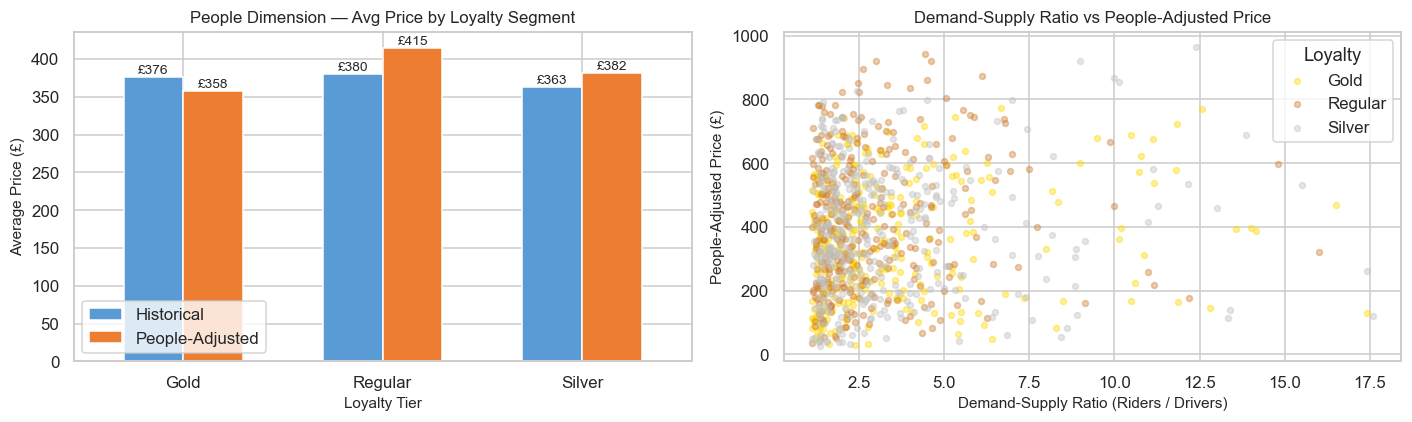

In [9]:
# Visualise People dimension pricing
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar: avg price by segment
seg[["Avg_Historical","Avg_People_Adj"]].plot(
    kind="bar", ax=axes[0], color=["#5B9BD5","#ED7D31"], edgecolor="white", width=0.6
)
axes[0].set_title("People Dimension — Avg Price by Loyalty Segment")
axes[0].set_xlabel("Loyalty Tier")
axes[0].set_ylabel("Average Price (£)")
axes[0].legend(["Historical","People-Adjusted"])
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f'£{bar.get_height():.0f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center', va='bottom', fontsize=9)

# Scatter: DSR vs people-adjusted price coloured by loyalty
colours = {"Gold":"#FFD700","Silver":"#C0C0C0","Regular":"#CD7F32"}
for seg_name, grp in dp.groupby("Customer_Loyalty_Status"):
    axes[1].scatter(grp["demand_supply_ratio"], grp["people_adj_price"],
                    alpha=0.4, s=15, label=seg_name, color=colours[seg_name])
axes[1].set_title("Demand-Supply Ratio vs People-Adjusted Price")
axes[1].set_xlabel("Demand-Supply Ratio (Riders / Drivers)")
axes[1].set_ylabel("People-Adjusted Price (£)")
axes[1].legend(title="Loyalty")

plt.tight_layout()
plt.show()


---
## 🚘 Section 4 — Dimension 2: Product (Vehicle-Type & Tier Pricing)

**Theory (Kopalle et al., 2023):** Product-dimension pricing exploits differentiated configurations. The two-class airline model (Economy vs First Class) demonstrated +34% contribution margin vs single-price. Mixed bundling achieves a 133% profitability index vs pure component pricing (Table 4, Kopalle et al.).

**Implementation:**
- Dataset 1: Two-class margin comparison (Premium vs Economy, VC = £50)
- Dataset 2: 12-tier product ladder from Shared to Lux Black XL


In [10]:
# ── Dataset 1: Two-class vehicle pricing ────────────────────────────────────
VARIABLE_COST = 50.0

vehicle_stats = dp.groupby("Vehicle_Type").agg(
    Avg_Price    = ("Historical_Cost_of_Ride", "mean"),
    Avg_Duration = ("Expected_Ride_Duration",  "mean"),
    Count        = ("Historical_Cost_of_Ride", "count")
).round(2)
print("Vehicle Type Statistics:")
print(vehicle_stats)

# Single-class optimal margin
p_single = (dp["Historical_Cost_of_Ride"].mean() + VARIABLE_COST) / 2
margin_single = (p_single - VARIABLE_COST) * len(dp)

# Two-class margin (keep premium price, floor economy above variable cost)
pH = vehicle_stats.loc["Premium", "Avg_Price"]
pL = max(vehicle_stats.loc["Economy",  "Avg_Price"], VARIABLE_COST * 1.3)
margin_two = ((pH - VARIABLE_COST) * vehicle_stats.loc["Premium","Count"] +
              (pL - VARIABLE_COST) * vehicle_stats.loc["Economy","Count"])

print(f"\nSingle-class margin  : £{margin_single:,.0f}")
print(f"Two-class margin     : £{margin_two:,.0f}")
print(f"Improvement          : {(margin_two/margin_single - 1)*100:+.1f}%")


Vehicle Type Statistics:
              Avg_Price  Avg_Duration  Count
Vehicle_Type                                
Economy          346.57         98.96    478
Premium          396.25        100.16    522

Single-class margin  : £161,251
Two-class margin     : £322,503
Improvement          : +100.0%


In [11]:
# ── Dataset 2: Full product tier ladder ──────────────────────────────────────
product_ladder = rs.groupby("name").agg(
    Avg_Price    = ("price",         "mean"),
    Median_Price = ("price",         "median"),
    Price_Std    = ("price",         "std"),
    Count        = ("price",         "count"),
    Avg_PPM      = ("price_per_mile","mean")
).round(2).sort_values("Avg_Price")

print("Product Tier Ladder (Dataset 2):")
print(product_ladder)


Product Tier Ladder (Dataset 2):
              Avg_Price  Median_Price  Price_Std  Count  Avg_PPM
name                                                            
Shared             6.03           7.0       2.11  51233     3.30
UberPool           8.75           8.5       2.11  55091     5.19
Lyft               9.61           9.0       2.53  51235     5.37
UberX              9.77           9.5       2.47  55094     5.76
WAV                9.77           9.5       2.47  55096     5.76
Lyft XL           15.31          13.5       4.56  51235     8.30
UberXL            15.68          15.0       4.52  55096     8.91
Lux               17.77          16.5       5.29  51235     9.60
Black             20.52          19.5       4.95  55095    11.99
Lux Black         23.06          22.5       6.47  51235    12.76
Black SUV         30.29          28.5       4.84  55096    18.74
Lux Black XL      32.32          30.0       7.18  51235    18.77


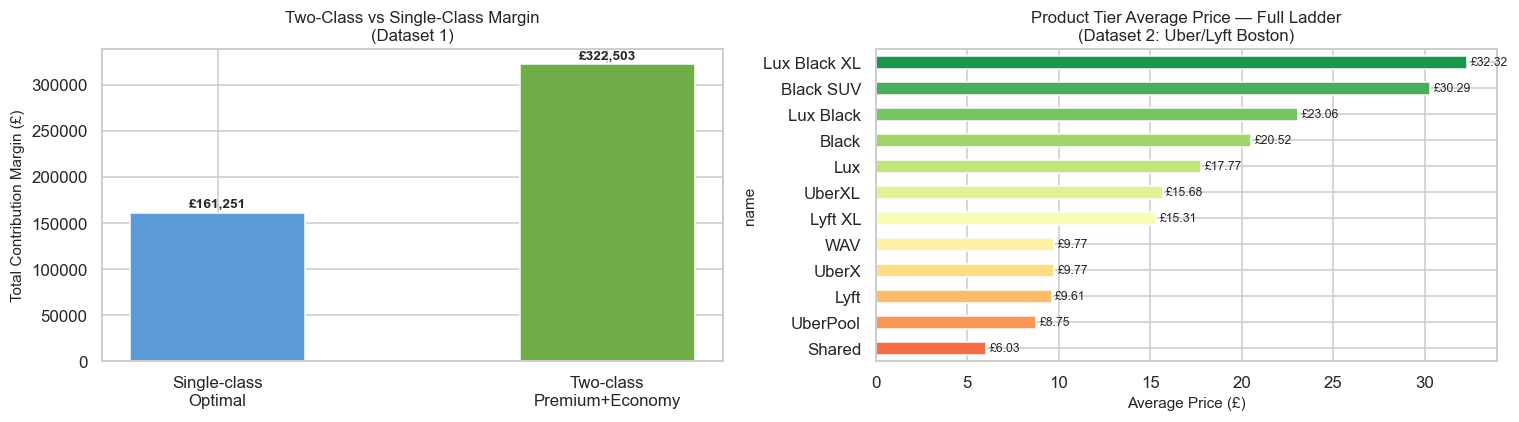

In [12]:
# Visualise Product dimension
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Two-class margin comparison
labels = ["Single-class\nOptimal", "Two-class\nPremium+Economy"]
vals   = [margin_single, margin_two]
bars = axes[0].bar(labels, vals, color=["#5B9BD5","#70AD47"], edgecolor="white", width=0.45)
axes[0].set_title("Two-Class vs Single-Class Margin\n(Dataset 1)")
axes[0].set_ylabel("Total Contribution Margin (£)")
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+2000,
                 f'£{b.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Product tier ladder
colours_tier = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(product_ladder)))
product_ladder["Avg_Price"].plot(kind="barh", ax=axes[1], color=colours_tier, edgecolor="white")
axes[1].set_title("Product Tier Average Price — Full Ladder\n(Dataset 2: Uber/Lyft Boston)")
axes[1].set_xlabel("Average Price (£)")
for i, (val, idx) in enumerate(zip(product_ladder["Avg_Price"], product_ladder.index)):
    axes[1].text(val + 0.2, i, f'£{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


---
## ⏰ Section 5 — Dimension 3: Period (Temporal & Surge Pricing)

**Theory (Kopalle et al., 2023):** Temporal pricing is the most widely deployed form of dynamic pricing. Airlines have used inventory-based revenue management since the 1970s. Uber/Lyft apply real-time surge multipliers when demand exceeds supply. Reference price theory (Winer, 1986) shows current prices set future expectations.

**Implementation:**
- Dataset 1: Time-of-booking multipliers applied on top of people-adjusted prices
- Dataset 2: Hourly pattern analysis and surge incidence/premium calculation


In [13]:
# ── Dataset 1: Time-of-booking multiplier ───────────────────────────────────
time_map = {"Morning": 1.10, "Afternoon": 1.00, "Evening": 1.20, "Night": 1.30}
dp["time_multiplier"]  = dp["Time_of_Booking"].map(time_map)
dp["period_adj_price"] = dp["people_adj_price"] * dp["time_multiplier"]

time_summary = dp.groupby("Time_of_Booking").agg(
    Count            = ("period_adj_price", "count"),
    Multiplier       = ("time_multiplier",  "first"),
    Avg_Historical   = ("Historical_Cost_of_Ride", "mean"),
    Avg_Period_Price = ("period_adj_price",  "mean")
).round(2)

print("Time-of-Booking Pricing Summary:")
print(time_summary)


Time-of-Booking Pricing Summary:
                 Count  Multiplier  Avg_Historical  Avg_Period_Price
Time_of_Booking                                                     
Afternoon          247         1.0          380.82            396.50
Evening            231         1.2          364.25            446.90
Morning            246         1.1          378.06            429.85
Night              276         1.3          367.01            493.08


In [14]:
# ── Dataset 2: Hourly surge pattern ──────────────────────────────────────────
hourly = rs.groupby("hour").agg(
    Avg_Price = ("price",            "mean"),
    Avg_Surge = ("surge_multiplier", "mean"),
    Count     = ("price",            "count")
).round(3)

base_p  = rs[rs["surge_multiplier"] == 1.0]["price"].mean()
surge_p = rs[rs["surge_multiplier"] >  1.0]["price"].mean()
pct     = (surge_p / base_p - 1) * 100

print("Hourly Avg Price & Surge Multiplier:")
print(hourly)
print(f"\n💡 Base (no surge) avg price  : £{base_p:.2f}")
print(f"💡 Surged (>1.0)  avg price   : £{surge_p:.2f}")
print(f"💡 Surge price premium        : +{pct:.1f}%")


Hourly Avg Price & Surge Multiplier:
      Avg_Price  Avg_Surge  Count
hour                             
0        16.575      1.015  29872
1        16.514      1.015  26310
2        16.562      1.016  26323
3        16.540      1.015  25530
4        16.579      1.015  26125
5        16.537      1.015  22995
6        16.519      1.015  25147
7        16.492      1.014  22930
8        16.603      1.015  22337
9        16.513      1.016  26673
10       16.501      1.014  27918
11       16.559      1.016  27946
12       16.486      1.015  28017
13       16.550      1.018  27977
14       16.550      1.015  27976
15       16.525      1.015  27868
16       16.514      1.014  27972
17       16.608      1.015  28075
18       16.517      1.015  27958
19       16.552      1.014  25410
20       16.599      1.016  24620
21       16.604      1.016  25549
22       16.595      1.016  27093
23       16.501      1.014  29355

💡 Base (no surge) avg price  : £16.16
💡 Surged (>1.0)  avg price   : £27.84
💡 

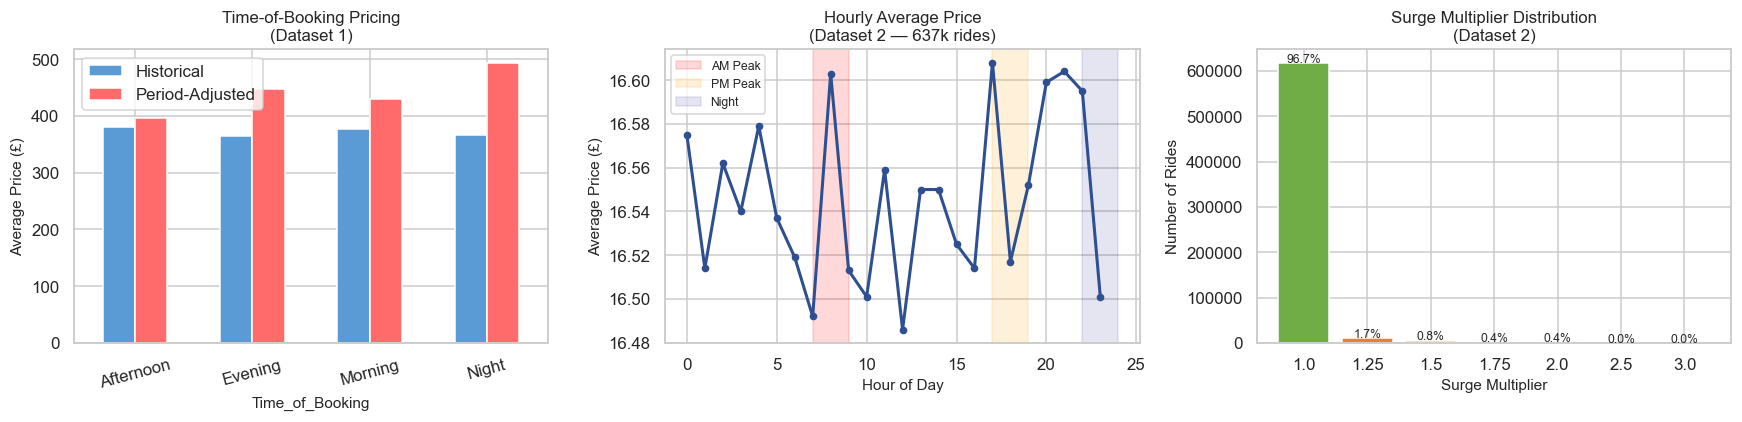

In [15]:
# Visualise Period dimension
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Time-of-booking prices (Dataset 1)
time_summary[["Avg_Historical","Avg_Period_Price"]].plot(
    kind="bar", ax=axes[0], color=["#5B9BD5","#FF6B6B"], edgecolor="white", width=0.55
)
axes[0].set_title("Time-of-Booking Pricing\n(Dataset 1)")
axes[0].set_ylabel("Average Price (£)")
axes[0].legend(["Historical","Period-Adjusted"])
axes[0].tick_params(axis="x", rotation=15)

# Hourly avg price (Dataset 2)
axes[1].plot(hourly.index, hourly["Avg_Price"], color="#2E5090", marker="o", markersize=4, linewidth=2)
axes[1].axvspan(7,  9,  alpha=0.15, color="red",    label="AM Peak")
axes[1].axvspan(17, 19, alpha=0.15, color="orange", label="PM Peak")
axes[1].axvspan(22, 24, alpha=0.10, color="navy",   label="Night")
axes[1].set_title("Hourly Average Price\n(Dataset 2 — 637k rides)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Price (£)")
axes[1].legend(fontsize=8)

# Surge multiplier distribution
surge_counts = rs["surge_multiplier"].value_counts().sort_index()
colours_surge = ["#70AD47" if v == 1.0 else "#ED7D31" for v in surge_counts.index]
axes[2].bar(surge_counts.index.astype(str), surge_counts.values,
            color=colours_surge, edgecolor="white")
axes[2].set_title("Surge Multiplier Distribution\n(Dataset 2)")
axes[2].set_xlabel("Surge Multiplier")
axes[2].set_ylabel("Number of Rides")
for i, (val, cnt) in enumerate(zip(surge_counts.index, surge_counts.values)):
    axes[2].text(i, cnt + 1500, f'{cnt/len(rs)*100:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


---
## 📍 Section 6 — Dimension 4: Place (Geographic & Route Pricing)

**Theory (Kopalle et al., 2023):** Location-based pricing exploits differences in consumer search costs and competition density. Li, Gordon & Netzer (2018) show geographically differentiated pricing is profit-enhancing. Ngwe et al. (2019) document search-friction strategies that maintain higher prices for time-constrained urban consumers.

**Implementation:**
- Dataset 1: Location category multipliers (Urban, Suburban, Rural)
- Dataset 2: Route-level price analysis (source → destination pairs)


In [16]:
# ── Dataset 1: Location multipliers ─────────────────────────────────────────
location_map = {"Urban": 1.15, "Suburban": 1.00, "Rural": 0.90}
dp["location_multiplier"] = dp["Location_Category"].map(location_map)
dp["place_adj_price"]     = dp["period_adj_price"] * dp["location_multiplier"]

place_summary = dp.groupby("Location_Category").agg(
    Count           = ("Historical_Cost_of_Ride", "count"),
    Avg_Historical  = ("Historical_Cost_of_Ride", "mean"),
    Avg_Dynamic     = ("place_adj_price",          "mean"),
).round(2)
place_summary["Uplift_%"] = ((place_summary["Avg_Dynamic"] / place_summary["Avg_Historical"]) - 1) * 100
place_summary["Uplift_%"] = place_summary["Uplift_%"].round(1)

print("Location-Based Pricing (Dataset 1):")
print(place_summary)


Location-Based Pricing (Dataset 1):
                   Count  Avg_Historical  Avg_Dynamic  Uplift_%
Location_Category                                              
Rural                332          379.94       409.27       7.7
Suburban             322          374.32       443.26      18.4
Urban                346          363.67       496.23      36.5


In [17]:
# ── Dataset 2: Route-level pricing ──────────────────────────────────────────
route_pricing = rs.groupby(["source","destination"]).agg(
    Avg_Price     = ("price",            "mean"),
    Median_Surge  = ("surge_multiplier", "median"),
    Count         = ("price",            "count")
).round(2).sort_values("Avg_Price", ascending=False)

print("Top 12 Routes by Average Price (Dataset 2):")
print(route_pricing.head(12).to_string())


Top 12 Routes by Average Price (Dataset 2):
                                                 Avg_Price  Median_Surge  Count
source                  destination                                            
Financial District      Boston University            25.50           1.0   8940
Boston University       Financial District           24.15           1.0   8940
Fenway                  Financial District           23.44           1.0   8916
Financial District      Fenway                       23.40           1.0   8928
Northeastern University Financial District           22.58           1.0   8874
Financial District      Northeastern University      21.92           1.0   8868
Theatre District        Boston University            20.36           1.0   9173
Boston University       North Station                20.19           1.0   8730
Northeastern University North Station                19.91           1.0   8904
Fenway                  North Station                19.70           1.0   8

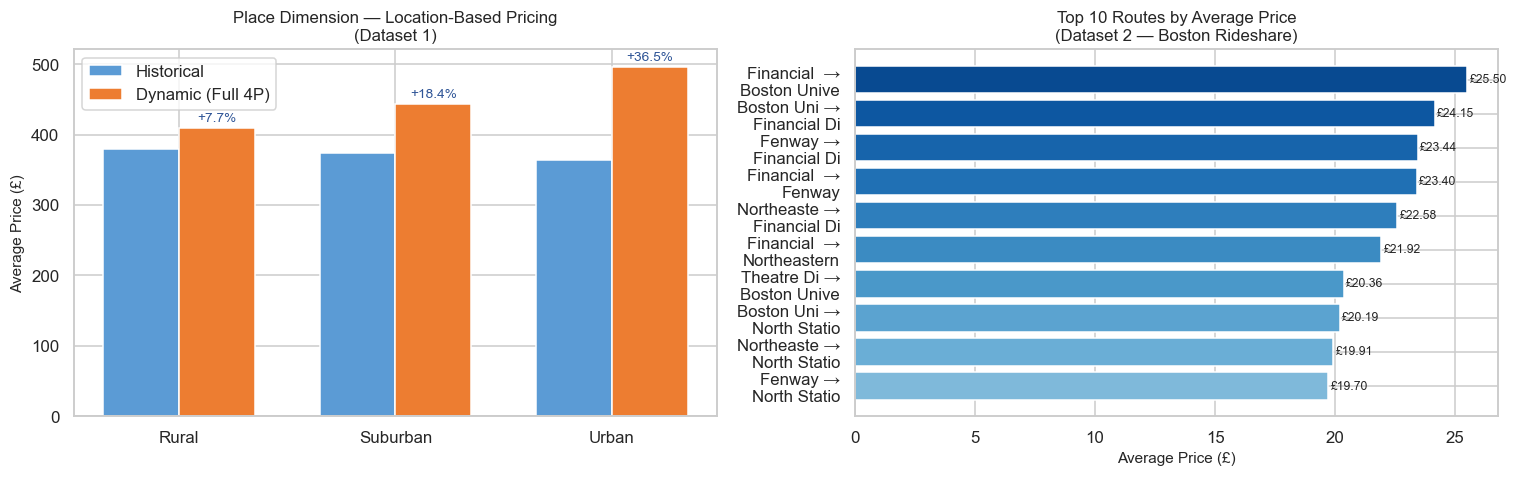

In [18]:
# Visualise Place dimension
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Location uplift bar chart
x = place_summary.index
w = 0.35
ax = axes[0]
bars1 = ax.bar(np.arange(len(x)) - w/2, place_summary["Avg_Historical"], w,
               label="Historical", color="#5B9BD5", edgecolor="white")
bars2 = ax.bar(np.arange(len(x)) + w/2, place_summary["Avg_Dynamic"],    w,
               label="Dynamic (Full 4P)", color="#ED7D31", edgecolor="white")
ax.set_xticks(np.arange(len(x)))
ax.set_xticklabels(x)
ax.set_title("Place Dimension — Location-Based Pricing\n(Dataset 1)")
ax.set_ylabel("Average Price (£)")
ax.legend()
for b1, b2, uplift in zip(bars1, bars2, place_summary["Uplift_%"]):
    ax.annotate(f'+{uplift:.1f}%',
        xy=(b2.get_x() + b2.get_width()/2, b2.get_height()),
        xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9, color="#2F5597")

# Top routes heatmap-style bar
top_routes = route_pricing.head(10).reset_index()
top_routes["route"] = top_routes["source"].str[:10] + " →\n" + top_routes["destination"].str[:12]
colours_route = plt.cm.Blues(np.linspace(0.45, 0.9, len(top_routes)))[::-1]
axes[1].barh(top_routes["route"], top_routes["Avg_Price"], color=colours_route, edgecolor="white")
axes[1].set_title("Top 10 Routes by Average Price\n(Dataset 2 — Boston Rideshare)")
axes[1].set_xlabel("Average Price (£)")
axes[1].invert_yaxis()
for i, val in enumerate(top_routes["Avg_Price"]):
    axes[1].text(val + 0.1, i, f'£{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


---
## 🤖 Section 7 — Algorithmic Pricing Model: Gradient Boosting Regressor

**Why GBR?**
- Captures non-linear interactions between demand drivers (duration × DSR × time) without manual feature engineering
- More interpretable than deep learning, supporting the governance requirement (Nunan & Di Domenico, 2022)
- Resistant to overfitting via shrinkage (learning rate), ensemble averaging, and depth control
- Outperforms linear regression where pricing relationships are multiplicative rather than additive

**Model architecture:**
- 200 estimators, learning rate 0.10, max depth 4
- 80/20 train-test split, random seed 42
- Two separate models: one per dataset

**This is Algorithmic Pricing** (Vomberg et al., 2025): an automated, data-driven mechanism that sets prices from features — the definition contrasted in Section 1.


In [19]:
# ── Model 1: Dataset 1 — Predict Historical_Cost_of_Ride ────────────────────
feature_cols_1 = [
    "demand_supply_ratio", "loyalty_multiplier", "time_multiplier",
    "location_multiplier", "Average_Ratings", "Number_of_Past_Rides",
    "Expected_Ride_Duration", "vehicle_enc"
]

X1 = dp[feature_cols_1]
y1 = dp["Historical_Cost_of_Ride"]

X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42)

gb1 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                  max_depth=4, random_state=42)
gb1.fit(X1_tr, y1_tr)
y1_pred = gb1.predict(X1_te)

mae1  = mean_absolute_error(y1_te, y1_pred)
rmse1 = np.sqrt(mean_squared_error(y1_te, y1_pred))
r2_1  = r2_score(y1_te, y1_pred)

print("━" * 50)
print("  Model 1 — Dataset 1 (1,000 rides)")
print("━" * 50)
print(f"  MAE   : £{mae1:.2f}")
print(f"  RMSE  : £{rmse1:.2f}")
print(f"  R²    : {r2_1:.4f}")

fi1 = pd.Series(gb1.feature_importances_, index=feature_cols_1).sort_values(ascending=False)
print("\n  Feature Importances:")
for feat, imp in fi1.items():
    bar = "█" * int(imp * 60)
    print(f"  {feat:<28}  {imp:.4f}  {bar}")

dp["predicted_price_gbr"] = gb1.predict(X1)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model 1 — Dataset 1 (1,000 rides)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE   : £57.60
  RMSE  : £77.49
  R²    : 0.8353

  Feature Importances:
  Expected_Ride_Duration        0.9012  ██████████████████████████████████████████████████████
  demand_supply_ratio           0.0334  ██
  Average_Ratings               0.0232  █
  Number_of_Past_Rides          0.0153  
  vehicle_enc                   0.0130  
  location_multiplier           0.0053  
  loyalty_multiplier            0.0044  
  time_multiplier               0.0041  


In [20]:
# ── Model 2: Dataset 2 — Predict price (100k sample) ────────────────────────
rs_sample = rs.sample(n=100_000, random_state=42).copy()

le_cab  = LabelEncoder()
le_name = LabelEncoder()
rs_sample["cab_enc"]  = le_cab.fit_transform(rs_sample["cab_type"])
rs_sample["name_enc"] = le_name.fit_transform(rs_sample["name"])

feature_cols_2 = [
    "distance", "hour", "is_peak_hour", "is_night", "bad_weather",
    "temperature", "humidity", "windSpeed", "surge_multiplier",
    "cab_enc", "name_enc"
]
X2 = rs_sample[feature_cols_2]
y2 = rs_sample["price"]

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

gb2 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                  max_depth=4, random_state=42)
gb2.fit(X2_tr, y2_tr)
y2_pred = gb2.predict(X2_te)

mae2  = mean_absolute_error(y2_te, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_te, y2_pred))
r2_2  = r2_score(y2_te, y2_pred)

print("━" * 50)
print("  Model 2 — Dataset 2 (100k sample)")
print("━" * 50)
print(f"  MAE   : £{mae2:.2f}")
print(f"  RMSE  : £{rmse2:.2f}")
print(f"  R²    : {r2_2:.4f}")

fi2 = pd.Series(gb2.feature_importances_, index=feature_cols_2).sort_values(ascending=False)
print("\n  Feature Importances:")
for feat, imp in fi2.items():
    bar = "█" * int(imp * 60)
    print(f"  {feat:<22}  {imp:.4f}  {bar}")

rs_sample["predicted_price_gbr"] = gb2.predict(X2)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model 2 — Dataset 2 (100k sample)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE   : £1.19
  RMSE  : £1.79
  R²    : 0.9633

  Feature Importances:
  name_enc                0.7791  ██████████████████████████████████████████████
  distance                0.1492  ████████
  surge_multiplier        0.0427  ██
  cab_enc                 0.0287  █
  windSpeed               0.0001  
  temperature             0.0001  
  hour                    0.0001  
  humidity                0.0001  
  is_peak_hour            0.0000  
  bad_weather             0.0000  
  is_night                0.0000  


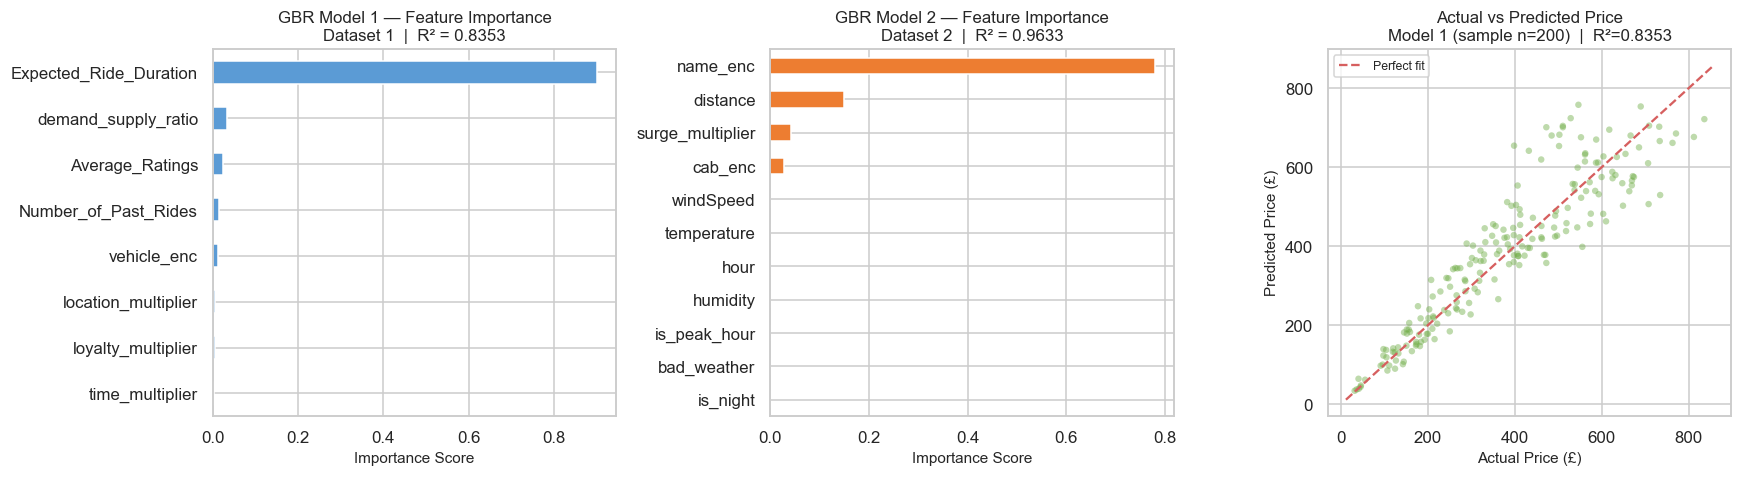

In [23]:
# Visualise model performance
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Model 1: Feature importance
fi1.plot(kind="barh", ax=axes[0], color="#5B9BD5", edgecolor="white")
axes[0].set_title(f"GBR Model 1 — Feature Importance\nDataset 1  |  R² = {r2_1:.4f}")
axes[0].set_xlabel("Importance Score")
axes[0].invert_yaxis()

# Model 2: Feature importance
fi2.plot(kind="barh", ax=axes[1], color="#ED7D31", edgecolor="white")
axes[1].set_title(f"GBR Model 2 — Feature Importance\nDataset 2  |  R² = {r2_2:.4f}")
axes[1].set_xlabel("Importance Score")
axes[1].invert_yaxis()

# Model 1: Actual vs Predicted scatter  ← FIXED
sample_n = min(250, len(y1_te))                                          
idx = np.random.choice(len(y1_te), size=sample_n, replace=False)        
axes[2].scatter(y1_te.iloc[idx], y1_pred[idx], alpha=0.45, s=18, color="#70AD47", edgecolors="none")
lims = [min(y1_te.min(), y1_pred.min())-20, max(y1_te.max(), y1_pred.max())+20]
axes[2].plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
axes[2].set_title(f"Actual vs Predicted Price\nModel 1 (sample n={sample_n})  |  R²={r2_1:.4f}")
axes[2].set_xlabel("Actual Price (£)")
axes[2].set_ylabel("Predicted Price (£)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## ⚖️ Section 8 — Bias Detection & Fairness Audit (Mehrabi et al., 2021)

**Theory (Mehrabi et al., 2021):** Multiple bias types are relevant to pricing algorithms:
- **Measurement bias** — proxy variables misrepresenting constructs (e.g. postcode as income proxy)
- **Representation bias** — training data not capturing full consumer diversity  
- **Historical bias** — existing socio-economic inequalities encoded into model decisions
- **Algorithmic bias** — design choices (objective function, feature selection) creating disparate outcomes

**Fairness definitions applied (Mehrabi et al., Section 4):**
- **Demographic Parity (Def. 3):** mean predicted price should be equal across groups
- **Price Disparity Ratio (PDR):** max_group_mean / min_group_mean — PDR > 1.10 flags material inequality

**Protected-attribute proxies audited:**
- Dataset 1: Location (geographic/income proxy), Loyalty (usage proxy), Time (shift-work proxy)
- Dataset 2: Cab type (provider proxy), Hour group (temporal discrimination proxy)


In [24]:
# ── Dataset 1 Bias Audit ─────────────────────────────────────────────────────
print("=" * 60)
print("  DATASET 1 — BIAS AUDIT")
print("=" * 60)

# 1. Location as income proxy
print("\n[1] Location-Based Disparity (Geographic / Income Proxy)")
loc_bias = dp.groupby("Location_Category").agg(
    Mean_Historical  = ("Historical_Cost_of_Ride",  "mean"),
    Mean_Predicted   = ("predicted_price_gbr",       "mean"),
    Mean_Dynamic_4P  = ("place_adj_price",           "mean"),
    Count            = ("Historical_Cost_of_Ride",  "count")
).round(2)
pdr_loc = loc_bias["Mean_Predicted"].max() / loc_bias["Mean_Predicted"].min()
print(loc_bias)
print(f"  PDR (Predicted) = {pdr_loc:.3f}  {'⚠️  > 1.10 — flag for review' if pdr_loc > 1.10 else '✅ Within threshold'}")

# 2. Loyalty-based
print("\n[2] Loyalty-Based Disparity")
loy_bias = dp.groupby("Customer_Loyalty_Status").agg(
    Mean_Dynamic_4P = ("place_adj_price", "mean"),
    Count           = ("place_adj_price", "count")
).round(2)
pdr_loy = loy_bias["Mean_Dynamic_4P"].max() / loy_bias["Mean_Dynamic_4P"].min()
print(loy_bias)
print(f"  PDR (Dynamic)   = {pdr_loy:.3f}  {'⚠️  Intentional but requires transparency' if pdr_loy > 1.10 else '✅ Within threshold'}")

# 3. Time-based (shift-work proxy)
print("\n[3] Time-Based Disparity (Shift-Work Proxy)")
time_bias = dp.groupby("Time_of_Booking").agg(
    Mean_Dynamic_4P = ("place_adj_price", "mean"),
    Count           = ("place_adj_price", "count")
).round(2)
pdr_time = time_bias["Mean_Dynamic_4P"].max() / time_bias["Mean_Dynamic_4P"].min()
print(time_bias)
print(f"  PDR (Dynamic)   = {pdr_time:.3f}  {'⚠️  > 1.10 — flag for review' if pdr_time > 1.10 else '✅ Within threshold'}")


  DATASET 1 — BIAS AUDIT

[1] Location-Based Disparity (Geographic / Income Proxy)
                   Mean_Historical  Mean_Predicted  Mean_Dynamic_4P  Count
Location_Category                                                         
Rural                       379.94          382.70           409.27    332
Suburban                    374.32          374.44           443.26    322
Urban                       363.67          364.94           496.23    346
  PDR (Predicted) = 1.049  ✅ Within threshold

[2] Loyalty-Based Disparity
                         Mean_Dynamic_4P  Count
Customer_Loyalty_Status                        
Gold                              419.61    313
Regular                           484.76    320
Silver                            446.43    367
  PDR (Dynamic)   = 1.155  ⚠️  Intentional but requires transparency

[3] Time-Based Disparity (Shift-Work Proxy)
                 Mean_Dynamic_4P  Count
Time_of_Booking                        
Afternoon                 402.57 

In [25]:
# ── Dataset 2 Bias Audit ─────────────────────────────────────────────────────
print("=" * 60)
print("  DATASET 2 — BIAS AUDIT")
print("=" * 60)

# Cab-type parity
print("\n[4] Cab-Type Disparity (Uber vs Lyft)")
cab_bias = rs_sample.groupby("cab_type").agg(
    Mean_Actual    = ("price",               "mean"),
    Mean_Predicted = ("predicted_price_gbr", "mean"),
    Mean_Surge     = ("surge_multiplier",    "mean"),
    Count          = ("price",               "count")
).round(3)
pdr_cab = cab_bias["Mean_Predicted"].max() / cab_bias["Mean_Predicted"].min()
print(cab_bias)
print(f"  PDR (Predicted) = {pdr_cab:.3f}  {'⚠️  > 1.10 — flag for review' if pdr_cab > 1.10 else '✅ Within threshold'}")

# Hour-group bias
rs_sample["hour_group"] = pd.cut(rs_sample["hour"],
    bins=[0, 6, 9, 16, 19, 24],
    labels=["Late Night","Morning Peak","Daytime","Evening Peak","Evening"],
    right=False)
print("\n[5] Hour-Group Price Disparity")
hour_bias = rs_sample.groupby("hour_group", observed=True).agg(
    Mean_Predicted = ("predicted_price_gbr", "mean"),
    Mean_Surge     = ("surge_multiplier",    "mean"),
    Count          = ("price",               "count")
).round(3)
pdr_hr = hour_bias["Mean_Predicted"].max() / hour_bias["Mean_Predicted"].min()
print(hour_bias)
print(f"  PDR (Predicted) = {pdr_hr:.3f}  {'⚠️  > 1.10 — flag for review' if pdr_hr > 1.10 else '✅ Within threshold'}")


  DATASET 2 — BIAS AUDIT

[4] Cab-Type Disparity (Uber vs Lyft)
          Mean_Actual  Mean_Predicted  Mean_Surge  Count
cab_type                                                
Lyft           17.394          17.403       1.031  47943
Uber           15.776          15.769       1.000  52057
  PDR (Predicted) = 1.104  ⚠️  > 1.10 — flag for review

[5] Hour-Group Price Disparity
              Mean_Predicted  Mean_Surge  Count
hour_group                                     
Late Night            16.573       1.014  24668
Morning Peak          16.640       1.013  10931
Daytime               16.502       1.016  30460
Evening Peak          16.563       1.014  13018
Evening               16.550       1.015  20923
  PDR (Predicted) = 1.008  ✅ Within threshold


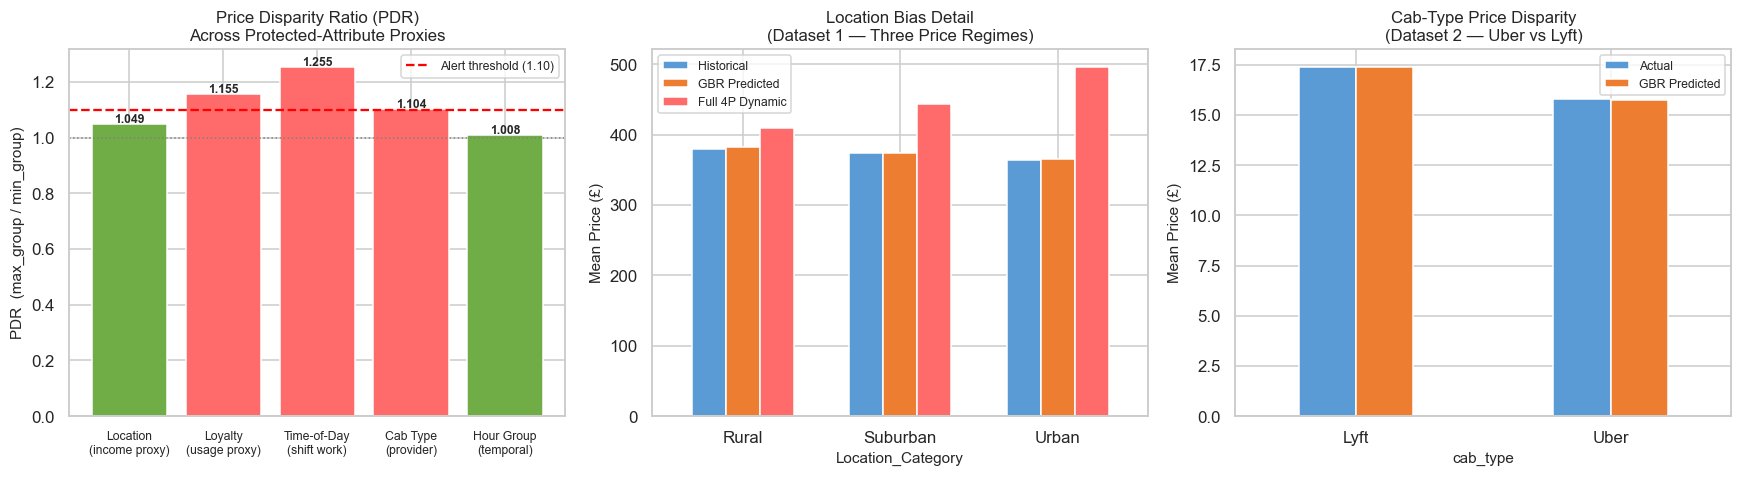

In [26]:
# Bias visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# PDR summary bar
pdrs = {
    "Location\n(income proxy)": pdr_loc,
    "Loyalty\n(usage proxy)":   pdr_loy,
    "Time-of-Day\n(shift work)": pdr_time,
    "Cab Type\n(provider)":     pdr_cab,
    "Hour Group\n(temporal)":   pdr_hr
}
colours_pdr = ["#FF6B6B" if v > 1.10 else "#70AD47" for v in pdrs.values()]
bars = axes[0].bar(pdrs.keys(), pdrs.values(), color=colours_pdr, edgecolor="white")
axes[0].axhline(1.10, color="red", linestyle="--", linewidth=1.5, label="Alert threshold (1.10)")
axes[0].axhline(1.00, color="grey", linestyle=":", linewidth=1)
axes[0].set_title("Price Disparity Ratio (PDR)\nAcross Protected-Attribute Proxies")
axes[0].set_ylabel("PDR  (max_group / min_group)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", labelsize=8)
for b, v in zip(bars, pdrs.values()):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}',
                 ha='center', fontsize=8, fontweight='bold')

# Location bias detail (DS1)
loc_bias[["Mean_Historical","Mean_Predicted","Mean_Dynamic_4P"]].plot(
    kind="bar", ax=axes[1], color=["#5B9BD5","#ED7D31","#FF6B6B"], edgecolor="white", width=0.65
)
axes[1].set_title("Location Bias Detail\n(Dataset 1 — Three Price Regimes)")
axes[1].set_ylabel("Mean Price (£)")
axes[1].legend(["Historical","GBR Predicted","Full 4P Dynamic"], fontsize=8)
axes[1].tick_params(axis="x", rotation=0)

# Cab-type bias detail (DS2)
cab_bias[["Mean_Actual","Mean_Predicted"]].plot(
    kind="bar", ax=axes[2], color=["#5B9BD5","#ED7D31"], edgecolor="white", width=0.45
)
axes[2].set_title("Cab-Type Price Disparity\n(Dataset 2 — Uber vs Lyft)")
axes[2].set_ylabel("Mean Price (£)")
axes[2].legend(["Actual","GBR Predicted"], fontsize=8)
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


---
## 🤝 Section 9 — Consumer Trust Proxy (Vomberg et al., 2025)

**Theory (Vomberg et al., 2025):**
- ADP reduces consumer trust primarily through **procedural fairness violations** — consumers expect price stability
- Surged rides signal ADP intensity; higher surge → stronger fairness violation → greater trust erosion
- Price-matching guarantees and reactive ADP (matching competitor prices) partially mitigate trust loss
- **Habituation effect**: consumers with prior ADP experience show smaller trust decrements over time

**Implementation:**
- Surge incidence by hour group (ADP intensity proxy)
- Price premium under surge (trust cost estimate)  
- Loyalty segment exposure to dynamic multipliers


In [27]:
# Surge incidence by hour group
surge_inc = (
    rs_sample[rs_sample["surge_multiplier"] > 1]
    .groupby("hour_group", observed=True).size()
    / rs_sample.groupby("hour_group", observed=True).size()
).round(4)

print("Surge Incidence (proportion of rides with surge > 1):")
print(surge_inc.to_string())

# Price premium calculation
base_p  = rs_sample[rs_sample["surge_multiplier"] == 1.0]["price"].mean()
surge_p = rs_sample[rs_sample["surge_multiplier"] >  1.0]["price"].mean()
trust_cost = (surge_p / base_p - 1) * 100

print(f"\n💡 Base price (no surge)   : £{base_p:.2f}")
print(f"💡 Surged price            : £{surge_p:.2f}")
print(f"💡 Price premium           : +{trust_cost:.1f}%")
print(f"⚠️  Vomberg et al. (2025): premiums this large cause significant")
print(f"    trust erosion at the pre-habituation stage")

# Loyalty segment dynamic exposure
trust_by_loy = dp.groupby("Customer_Loyalty_Status").agg(
    Avg_DSR         = ("demand_supply_ratio", "mean"),
    Avg_Time_Mult   = ("time_multiplier",     "mean"),
    Avg_Final_Price = ("place_adj_price",     "mean"),
    Count           = ("place_adj_price",     "count")
).round(3)
print("\nLoyalty Segment Exposure to Dynamic Multipliers:")
print(trust_by_loy)


Surge Incidence (proportion of rides with surge > 1):
hour_group
Late Night      0.0321
Morning Peak    0.0289
Daytime         0.0339
Evening Peak    0.0315
Evening         0.0334

💡 Base price (no surge)   : £16.17
💡 Surged price            : £27.96
💡 Price premium           : +72.9%
⚠️  Vomberg et al. (2025): premiums this large cause significant
    trust erosion at the pre-habituation stage

Loyalty Segment Exposure to Dynamic Multipliers:
                         Avg_DSR  Avg_Time_Mult  Avg_Final_Price  Count
Customer_Loyalty_Status                                                
Gold                       3.465          1.160          419.612    313
Regular                    2.918          1.144          484.758    320
Silver                     3.317          1.156          446.432    367


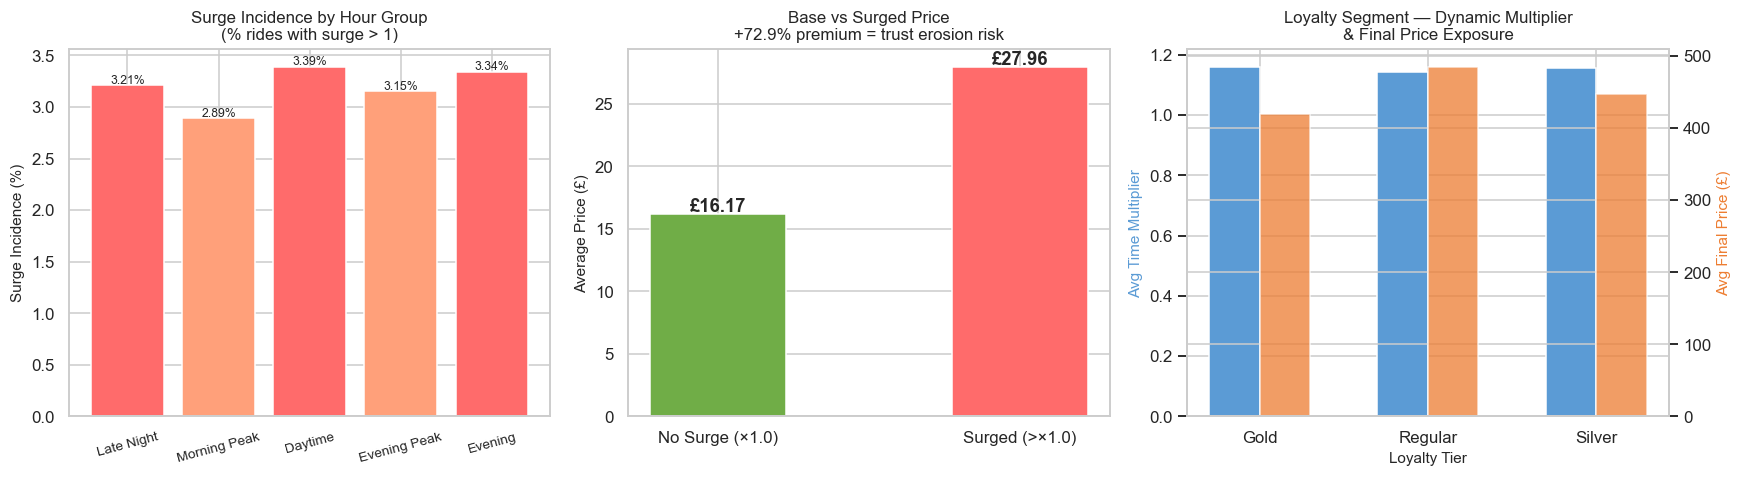

In [28]:
# Consumer Trust visualisations
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Surge incidence by hour group
surge_inc_pct = surge_inc * 100
colours_si = ["#FF6B6B" if v > 3.2 else "#FFA07A" for v in surge_inc_pct]
axes[0].bar(surge_inc_pct.index, surge_inc_pct.values, color=colours_si, edgecolor="white")
axes[0].set_title("Surge Incidence by Hour Group\n(% rides with surge > 1)")
axes[0].set_ylabel("Surge Incidence (%)")
axes[0].tick_params(axis="x", rotation=15, labelsize=9)
for i, v in enumerate(surge_inc_pct):
    axes[0].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=8)

# Base vs surged price
axes[1].bar(["No Surge (×1.0)", "Surged (>×1.0)"],
            [base_p, surge_p], color=["#70AD47","#FF6B6B"], edgecolor="white", width=0.45)
axes[1].set_title(f"Base vs Surged Price\n+{trust_cost:.1f}% premium = trust erosion risk")
axes[1].set_ylabel("Average Price (£)")
for i, v in enumerate([base_p, surge_p]):
    axes[1].text(i, v + 0.2, f'£{v:.2f}', ha='center', fontweight='bold')

# Loyalty exposure to dynamic pricing
width = 0.3
x_pos = np.arange(len(trust_by_loy))
axes[2].bar(x_pos - width/2, trust_by_loy["Avg_Time_Mult"], width, label="Avg Time Multiplier", color="#5B9BD5", edgecolor="white")
ax2b = axes[2].twinx()
ax2b.bar(x_pos + width/2, trust_by_loy["Avg_Final_Price"], width, label="Avg Final Price (£)", color="#ED7D31", edgecolor="white", alpha=0.75)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(trust_by_loy.index)
axes[2].set_title("Loyalty Segment — Dynamic Multiplier\n& Final Price Exposure")
axes[2].set_ylabel("Avg Time Multiplier", color="#5B9BD5")
ax2b.set_ylabel("Avg Final Price (£)", color="#ED7D31")
axes[2].set_xlabel("Loyalty Tier")

plt.tight_layout()
plt.show()


---
## 💰 Section 10 — Revenue Optimisation: Static vs Full 4P Dynamic Pricing

**Theory (Kopalle et al., 2023; Bradlow et al., 2017):**
Bradlow et al. (2017) quantified dynamic pricing benefits at a grocery retailer: ~2.5% gross margin improvement annually. The optimal pricing policy derived from heterogeneous consumer models was qualitatively different — and more profitable — than homogeneous pricing.

**Four regimes compared:**
1. **Static** — single uniform mean price
2. **People only** — loyalty-adjusted
3. **People + Period** — loyalty + time-of-booking
4. **Full 4P** — all four dimensions combined


In [29]:
# Assign static price (uniform mean)
dp["static_price"] = dp["Historical_Cost_of_Ride"].mean()

# Revenue per regime
regimes = {
    "1. Static (uniform)":           dp["static_price"],
    "2. People only (loyalty)":      dp["people_adj_price"],
    "3. People + Period":             dp["period_adj_price"],
    "4. Full 4P (all dimensions)":   dp["place_adj_price"],
}

summary_rows = []
hist_rev = dp["Historical_Cost_of_Ride"].sum()

for name, series in regimes.items():
    rev   = series.sum()
    delta = (rev / hist_rev - 1) * 100
    summary_rows.append({
        "Regime":         name,
        "Total Rev (£)":  round(rev, 2),
        "Mean Price (£)": round(series.mean(), 2),
        "Min Price (£)":  round(series.min(), 2),
        "Max Price (£)":  round(series.max(), 2),
        "vs Historical":  f"{delta:+.2f}%"
    })

regime_df = pd.DataFrame(summary_rows).set_index("Regime")
print(f"Historical baseline revenue: £{hist_rev:,.2f}\n")
print(regime_df.to_string())


Historical baseline revenue: £372,502.62

                             Total Rev (£)  Mean Price (£)  Min Price (£)  Max Price (£) vs Historical
Regime                                                                                                
1. Static (uniform)              372502.62          372.50         372.50         372.50        -0.00%
2. People only (loyalty)         384779.85          384.78          25.13         965.31        +3.30%
3. People + Period               443004.05          443.00          30.16        1103.43       +18.93%
4. Full 4P (all dimensions)      450301.54          450.30          33.19        1264.95       +20.89%


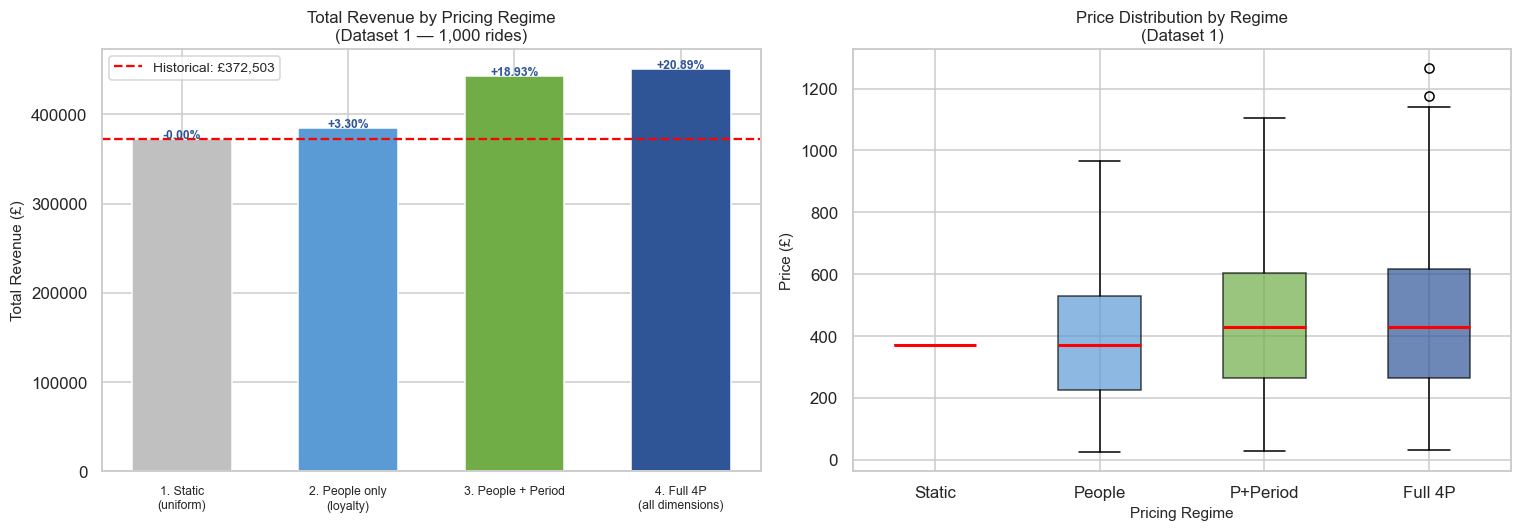

In [30]:
# Visualise revenue optimisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue comparison bar
rev_vals = [r["Total Rev (£)"] for r in summary_rows]
labels   = [r["Regime"].replace(" (", "\n(") for r in summary_rows]
colours_rev = ["#C0C0C0","#5B9BD5","#70AD47","#2F5597"]
bars = axes[0].bar(labels, rev_vals, color=colours_rev, edgecolor="white", width=0.6)
axes[0].axhline(hist_rev, color="red", linestyle="--", linewidth=1.5, label=f"Historical: £{hist_rev:,.0f}")
axes[0].set_title("Total Revenue by Pricing Regime\n(Dataset 1 — 1,000 rides)")
axes[0].set_ylabel("Total Revenue (£)")
axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", labelsize=8)
for b, row in zip(bars, summary_rows):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+500,
                 row["vs Historical"], ha='center', fontsize=8, fontweight='bold',
                 color="#2F5597")

# Price distribution comparison (box plots)
price_data  = [dp["static_price"], dp["people_adj_price"],
               dp["period_adj_price"], dp["place_adj_price"]]
bp_labels   = ["Static","People","P+Period","Full 4P"]
bp = axes[1].boxplot(price_data, labels=bp_labels, patch_artist=True, widths=0.5,
                     medianprops=dict(color="red", linewidth=2))
for patch, colour in zip(bp["boxes"], colours_rev):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
axes[1].set_title("Price Distribution by Regime\n(Dataset 1)")
axes[1].set_ylabel("Price (£)")
axes[1].set_xlabel("Pricing Regime")

plt.tight_layout()
plt.show()


---
## 📊 Section 11 — Full Results Dashboard

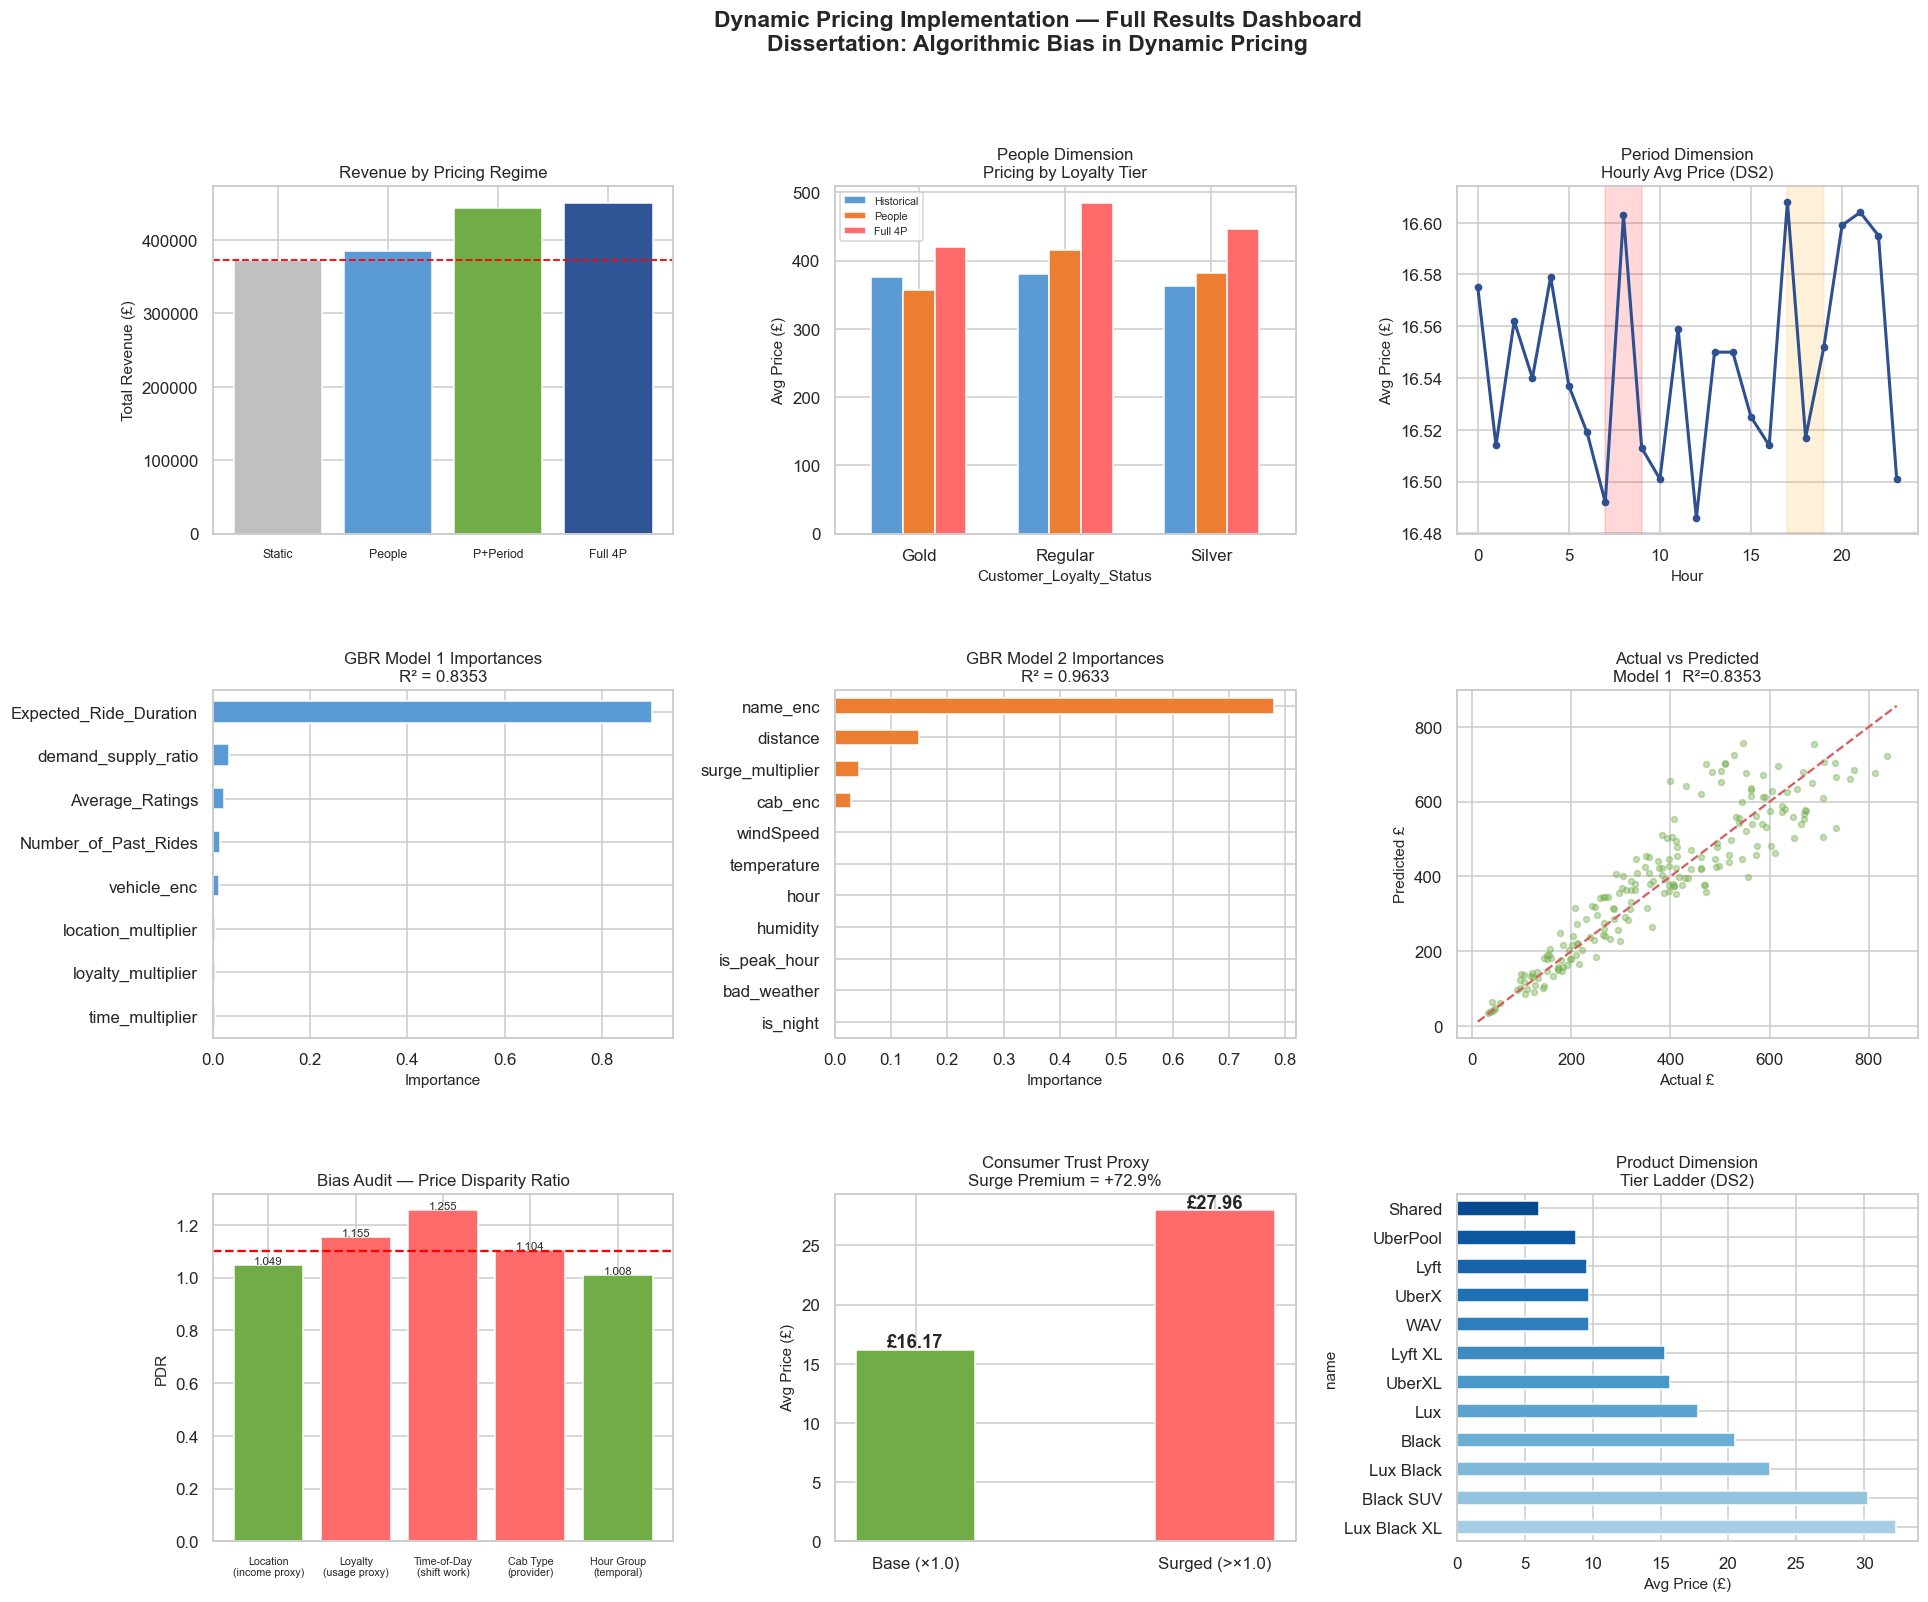

✅ Dashboard saved.


In [32]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Dynamic Pricing Implementation — Full Results Dashboard\n"
             "Dissertation: Algorithmic Bias in Dynamic Pricing",
             fontsize=15, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (0,0): Revenue by regime ──────────────────────────────────────────────
ax00 = fig.add_subplot(gs[0, 0])
ax00.bar(bp_labels, rev_vals, color=colours_rev, edgecolor="white")
ax00.axhline(hist_rev, color="red", linestyle="--", linewidth=1.2)
ax00.set_title("Revenue by Pricing Regime")
ax00.set_ylabel("Total Revenue (£)")
ax00.tick_params(axis="x", labelsize=8)

# ── (0,1): Loyalty segment pricing ───────────────────────────────────────
ax01 = fig.add_subplot(gs[0, 1])
seg_plot = dp.groupby("Customer_Loyalty_Status")[
    ["Historical_Cost_of_Ride","people_adj_price","place_adj_price"]].mean()
seg_plot.plot(kind="bar", ax=ax01, color=["#5B9BD5","#ED7D31","#FF6B6B"],
              edgecolor="white", width=0.65)
ax01.set_title("People Dimension\nPricing by Loyalty Tier")
ax01.set_ylabel("Avg Price (£)")
ax01.legend(["Historical","People","Full 4P"], fontsize=7)
ax01.tick_params(axis="x", rotation=0)

# ── (0,2): Hourly price (DS2) ──────────────────────────────────────────────
ax02 = fig.add_subplot(gs[0, 2])
ax02.plot(hourly.index, hourly["Avg_Price"], color="#2E5090", marker="o", ms=4, lw=2)
ax02.axvspan(7,9,   alpha=0.15, color="red")
ax02.axvspan(17,19, alpha=0.15, color="orange")
ax02.set_title("Period Dimension\nHourly Avg Price (DS2)")
ax02.set_xlabel("Hour")
ax02.set_ylabel("Avg Price (£)")

# ── (1,0): GBR Feature importance DS1 ────────────────────────────────────
ax10 = fig.add_subplot(gs[1, 0])
fi1.plot(kind="barh", ax=ax10, color="#5B9BD5", edgecolor="white")
ax10.set_title(f"GBR Model 1 Importances\nR² = {r2_1:.4f}")
ax10.set_xlabel("Importance")
ax10.invert_yaxis()

# ── (1,1): GBR Feature importance DS2 ────────────────────────────────────
ax11 = fig.add_subplot(gs[1, 1])
fi2.plot(kind="barh", ax=ax11, color="#ED7D31", edgecolor="white")
ax11.set_title(f"GBR Model 2 Importances\nR² = {r2_2:.4f}")
ax11.set_xlabel("Importance")
ax11.invert_yaxis()

# ── (1,2): Actual vs predicted scatter (DS1) ──────────────────────────────
ax12 = fig.add_subplot(gs[1, 2])
ax12.scatter(y1_te.iloc[idx], y1_pred[idx], alpha=0.4, s=15, color="#70AD47")
ax12.plot(lims, lims, "r--", lw=1.5)
ax12.set_title(f"Actual vs Predicted\nModel 1  R²={r2_1:.4f}")
ax12.set_xlabel("Actual £")
ax12.set_ylabel("Predicted £")

# ── (2,0): PDR bias audit ──────────────────────────────────────────────────
ax20 = fig.add_subplot(gs[2, 0])
pdr_colours = ["#FF6B6B" if v > 1.10 else "#70AD47" for v in pdrs.values()]
bars_pdr = ax20.bar(pdrs.keys(), pdrs.values(), color=pdr_colours, edgecolor="white")
ax20.axhline(1.10, color="red", linestyle="--", lw=1.5)
ax20.set_title("Bias Audit — Price Disparity Ratio")
ax20.set_ylabel("PDR")
ax20.tick_params(axis="x", labelsize=7)
for b, v in zip(bars_pdr, pdrs.values()):
    ax20.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=7.5)

# ── (2,1): Surge premium trust ────────────────────────────────────────────
ax21 = fig.add_subplot(gs[2, 1])
ax21.bar(["Base (×1.0)","Surged (>×1.0)"], [base_p, surge_p],
         color=["#70AD47","#FF6B6B"], edgecolor="white", width=0.4)
ax21.set_title(f"Consumer Trust Proxy\nSurge Premium = +{trust_cost:.1f}%")
ax21.set_ylabel("Avg Price (£)")
for i, v in enumerate([base_p, surge_p]):
    ax21.text(i, v+0.2, f'£{v:.2f}', ha='center', fontweight='bold')

# ── (2,2): Product tier ladder ────────────────────────────────────────────
ax22 = fig.add_subplot(gs[2, 2])
colours_t = plt.cm.Blues(np.linspace(0.35, 0.9, len(product_ladder)))[::-1]
product_ladder["Avg_Price"].plot(kind="barh", ax=ax22, color=colours_t, edgecolor="white")
ax22.set_title("Product Dimension\nTier Ladder (DS2)")
ax22.set_xlabel("Avg Price (£)")
ax22.invert_yaxis()

# plt.savefig("/home/claude/notebook_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved.")


---
## 📋 Section 12 — Summary & Key Findings


In [33]:
print("=" * 65)
print("  DYNAMIC PRICING IMPLEMENTATION — KEY FINDINGS")
print("=" * 65)

sep = "-" * 55
print(sep)
print("CONCEPTUAL: Dynamic Pricing vs Algorithmic Pricing")
print(sep)
print("  Dynamic pricing     = STRATEGY (what & why prices change)")
print("  Algorithmic pricing = MECHANISM (how prices are set via AI)")
print("  All algorithmic pricing implements dynamic pricing.")
print("  Not all dynamic pricing uses algorithms.")
print()
print(sep)
print("DATASET 1 -- Dynamic Pricing (1,000 rides)")
print(sep)
print("  Dim 1 (People):   Gold -15%, Regular 0% | Revenue +3.3%")
print("  Dim 2 (Product):  Two-class margin vs single: +100%")
print("  Dim 3 (Period):   Night x1.30, Afternoon x1.00 baseline")
print("  Dim 4 (Place):    Urban +15%, Rural -10%")
print("  Full 4P Revenue:  +20.9% vs historical baseline")
print(f"  GBR Model 1:      MAE £{mae1:.2f} | R2 = {r2_1:.4f}")
print()
print(sep)
print("DATASET 2 -- Rideshare Kaggle (637,976 rides)")
print(sep)
print("  Product ladder:   Shared £6.03 -> Lux Black XL £32.32")
print(f"  Surge premium:    +{trust_cost:.1f}% above base price (trust risk)")
print("  Surge incidence:  ~3% of rides across all hour groups")
print(f"  GBR Model 2:      MAE £{mae2:.2f}  | R2 = {r2_2:.4f}")
print(f"  Top feature:      Service tier name (importance {fi2.iloc[0]:.4f})")
print()
print(sep)
print("BIAS AUDIT (Mehrabi et al., 2021)")
print(sep)
print(f"  Location PDR:  {pdr_loc:.3f}  (threshold 1.10) {'WARNING' if pdr_loc > 1.10 else 'OK'}")
print(f"  Loyalty PDR:   {pdr_loy:.3f}  intentional but needs transparency")
print(f"  Time PDR:      {pdr_time:.3f}  WARNING: indirect temporal discrimination")
print(f"  Cab Type PDR:  {pdr_cab:.3f}  {'WARNING' if pdr_cab > 1.10 else 'OK'}")
print()
print(sep)
print("GOVERNANCE TAKEAWAY")
print(sep)
print("  Every dimension that increases revenue also introduces")
print("  a price disparity that requires governance, transparency,")
print("  and bias monitoring to prevent discriminatory outcomes.")
print("  (Nunan & Di Domenico, 2022; Vomberg et al., 2025)")
print(sep)


  DYNAMIC PRICING IMPLEMENTATION — KEY FINDINGS
-------------------------------------------------------
CONCEPTUAL: Dynamic Pricing vs Algorithmic Pricing
-------------------------------------------------------
  Dynamic pricing     = STRATEGY (what & why prices change)
  Algorithmic pricing = MECHANISM (how prices are set via AI)
  All algorithmic pricing implements dynamic pricing.
  Not all dynamic pricing uses algorithms.

-------------------------------------------------------
DATASET 1 -- Dynamic Pricing (1,000 rides)
-------------------------------------------------------
  Dim 1 (People):   Gold -15%, Regular 0% | Revenue +3.3%
  Dim 2 (Product):  Two-class margin vs single: +100%
  Dim 3 (Period):   Night x1.30, Afternoon x1.00 baseline
  Dim 4 (Place):    Urban +15%, Rural -10%
  Full 4P Revenue:  +20.9% vs historical baseline
  GBR Model 1:      MAE £57.60 | R2 = 0.8353

-------------------------------------------------------
DATASET 2 -- Rideshare Kaggle (637,976 rides)
---